# Exp5 Benchmark Analysis

Evaluate contact prediction from saved rollouts. Uses CASP-style metrics
(precision at top L/5, L/2, L; short/medium/long separation ranges) but
with a different contact definition than CASP:

- **Our definition**: closest heavy-atom pair < 4.0A, |i-j| >= 2
- **CASP definition**: CB-CB < 8.0A, |i-j| >= 6

Our 4A all-atom cutoff is much stricter, producing fewer contacts especially
at medium and long range. Absolute precision values are **not** directly
comparable to published CASP tables, but comparisons between methods
(exp5 vs ESMFold vs random) on the same GT are valid.

Ground truth comes from AlphaFold DB predicted structures (training data),
not experimental PDB structures.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
%matplotlib inline

RESULTS_PATH = "../../results/benchmark_exp5.jsonl"
ESMFOLD_PATH = "../../results/benchmark_esmfold.jsonl"  # optional, set to None if not available

# Load raw rollout data
records = []
with open(RESULTS_PATH) as f:
    for line in f:
        records.append(json.loads(line))
print(f"Loaded {len(records)} proteins")
print(f"Seq len: {min(r['seq_len'] for r in records)}-{max(r['seq_len'] for r in records)}, "
      f"median={np.median([r['seq_len'] for r in records]):.0f}")

# Load ESMFold results if available
import os
esmfold_records = {}
if ESMFOLD_PATH and os.path.exists(ESMFOLD_PATH):
    with open(ESMFOLD_PATH) as f:
        for line in f:
            rec = json.loads(line)
            esmfold_records[rec["entry_id"]] = rec
    print(f"Loaded ESMFold results for {len(esmfold_records)} proteins")
else:
    print("No ESMFold results found (set ESMFOLD_PATH to include)")

Loaded 100 proteins
Seq len: 59-958, median=193
Loaded ESMFold results for 100 proteins


In [2]:
# Core evaluation functions

# CASP separation ranges
CASP_RANGES = {
    "short": (6, 12),
    "medium": (12, 24),
    "long": (24, None),
    "all_6+": (6, None),  # all non-trivial contacts
}

def parse_contacts(contact_list):
    """Convert serialized contacts back to tuples."""
    return [(c[0], c[1], c[2], c[3], c[4], c[5]) for c in contact_list]

def contacts_to_lt4_pairs(contacts):
    """Extract bin_lt4 residue pairs."""
    return {(min(c[1], c[2]), max(c[1], c[2])) for c in contacts if c[5] == "bin_lt4"}

def rollouts_to_scored_pairs(rollouts, seq_len):
    """Convert rollouts to (pair, frequency) scored list, sorted by decreasing score."""
    freq = defaultdict(int)
    n = len(rollouts)
    for rollout in rollouts:
        contacts = parse_contacts(rollout["contacts"])
        for pair in contacts_to_lt4_pairs(contacts):
            freq[pair] += 1
    scored = [(pair, count / n) for pair, count in freq.items()]
    scored.sort(key=lambda x: -x[1])
    return scored

def esmfold_to_scored_pairs(esmfold_rec, gt_set=None):
    """Convert ESMFold contacts to scored pairs.
    
    ESMFold has no per-contact confidence ranking. We score by how close
    the contact's separation is to the median GT separation (as a rough proxy
    for relevance), but this only affects tie-breaking for top-K metrics.
    For the "all predicted" metric, order doesn't matter.
    """
    pairs = [tuple(p) for p in esmfold_rec["predicted_contacts"]]
    # Score by inverse separation (short-range contacts are more likely correct,
    # so this gives a fair ranking for top-K evaluation)
    scored = [((p[0], p[1]), 1.0 / max(abs(p[0] - p[1]), 1)) for p in pairs]
    scored.sort(key=lambda x: -x[1])
    return scored

def precision_at_k(scored_pairs, gt_set, k, sep_range=None):
    """Precision of the top-k predictions."""
    if sep_range is not None:
        min_sep, max_sep = sep_range
        filtered = [(p, s) for p, s in scored_pairs
                    if abs(p[0] - p[1]) >= min_sep and
                    (max_sep is None or abs(p[0] - p[1]) < max_sep)]
        gt_filtered = {p for p in gt_set
                      if abs(p[0] - p[1]) >= min_sep and
                      (max_sep is None or abs(p[0] - p[1]) < max_sep)}
    else:
        filtered = scored_pairs
        gt_filtered = gt_set
    
    top_k = [p for p, s in filtered[:k]]
    if not top_k:
        return 0.0, 0, len(gt_filtered)
    correct = sum(1 for p in top_k if p in gt_filtered)
    return correct / len(top_k), correct, len(gt_filtered)

def random_baseline_precision(seq_len, gt_set, k, sep_range):
    """Expected precision from random predictions (analytical)."""
    min_sep, max_sep = sep_range
    n_possible = sum(1 for i in range(1, seq_len + 1)
                     for j in range(i + 1, seq_len + 1)
                     if abs(i - j) >= min_sep and (max_sep is None or abs(i - j) < max_sep))
    gt_filtered = {p for p in gt_set
                  if abs(p[0] - p[1]) >= min_sep and (max_sep is None or abs(p[0] - p[1]) < max_sep)}
    if not n_possible or not gt_filtered:
        return 0.0
    return len(gt_filtered) / n_possible

print("Evaluation functions ready.")

Evaluation functions ready.


In [3]:
# Compute CASP metrics for all proteins and conditions (including ESMFold)
MIN_GT_PER_RANGE = 5  # skip protein/range combos with fewer than this many GT contacts

results_rows = []

CONDITIONS = ["seq_only", "with_longest"]
if esmfold_records:
    CONDITIONS.append("esmfold")

n_skipped = defaultdict(int)

for rec in records:
    seq_len = rec["seq_len"]
    L = seq_len
    gt_contacts = parse_contacts(rec["gt_contacts"])
    gt_lt4 = contacts_to_lt4_pairs(gt_contacts)
    entry_id = rec["entry_id"]
    
    for condition in CONDITIONS:
        if condition in ("seq_only", "with_longest"):
            rollouts = rec[condition]
            scored = rollouts_to_scored_pairs(rollouts, seq_len)
        elif condition == "esmfold":
            if entry_id not in esmfold_records:
                continue
            scored = esmfold_to_scored_pairs(esmfold_records[entry_id])
        
        for range_name, sep_range in CASP_RANGES.items():
            min_sep, max_sep = sep_range
            gt_in_range = {p for p in gt_lt4
                          if abs(p[0]-p[1]) >= min_sep and (max_sep is None or abs(p[0]-p[1]) < max_sep)}
            
            if len(gt_in_range) < MIN_GT_PER_RANGE:
                n_skipped[range_name] += 1
                continue
            
            for k_name, k_val in [("L/5", max(1, L // 5)), ("L/2", max(1, L // 2)), ("L", L)]:
                prec, correct, n_gt = precision_at_k(scored, gt_lt4, k_val, sep_range)
                rand_prec = random_baseline_precision(seq_len, gt_lt4, k_val, sep_range)
                
                results_rows.append({
                    "entry_id": entry_id,
                    "seq_len": seq_len,
                    "condition": condition,
                    "range": range_name,
                    "k_name": k_name,
                    "k_val": k_val,
                    "precision": prec,
                    "n_correct": correct,
                    "n_gt": n_gt,
                    "n_pred": min(k_val, len([(p,s) for p,s in scored
                                              if abs(p[0]-p[1]) >= min_sep and
                                              (max_sep is None or abs(p[0]-p[1]) < max_sep)])),
                    "random_precision": rand_prec,
                    "longest_sep": rec["longest_contact_sep"],
                })

df = pd.DataFrame(results_rows)
print(f"{len(df)} metric rows (after filtering)")
print(f"Conditions: {df['condition'].unique().tolist()}")
print(f"MIN_GT_PER_RANGE = {MIN_GT_PER_RANGE}")
print(f"\nProteins skipped per range (fewer than {MIN_GT_PER_RANGE} GT contacts):")
for range_name in ["short", "medium", "long", "all_6+"]:
    # n_skipped counts across all conditions, divide by n_conditions
    n_cond = len(CONDITIONS)
    skipped = n_skipped[range_name] // n_cond
    total = len(records)
    kept = total - skipped
    print(f"  {range_name:>8s}: {skipped:3d}/{total} skipped, {kept:3d} kept")

3474 metric rows (after filtering)
Conditions: ['seq_only', 'with_longest', 'esmfold']
MIN_GT_PER_RANGE = 5

Proteins skipped per range (fewer than 5 GT contacts):
     short:   4/100 skipped,  96 kept
    medium:   4/100 skipped,  96 kept
      long:   5/100 skipped,  95 kept
    all_6+:   1/100 skipped,  99 kept


In [4]:
# Summary table: CASP-style metrics (both macro and micro averaged)
all_conditions = [c for c in ["seq_only", "with_longest", "esmfold"] if c in df["condition"].values]

# Macro average (mean of per-protein precision)
print("=" * 90)
print("MACRO-AVERAGED PRECISION (mean of per-protein precision)")
print(f"Proteins with >= {MIN_GT_PER_RANGE} GT contacts in each range")
print("=" * 90)

for condition in all_conditions:
    print(f"\n--- {condition} ---")
    print(f"{'Range':<12s} {'N':>4s} {'Top L/5':>10s} {'Top L/2':>10s} {'Top L':>10s}  |  {'Random':>10s}")
    print("-" * 60)
    for range_name in ["short", "medium", "long", "all_6+"]:
        vals = []
        n_proteins = 0
        for k_name in ["L/5", "L/2", "L"]:
            sub = df[(df["condition"]==condition) & (df["range"]==range_name) & (df["k_name"]==k_name)]
            vals.append(sub["precision"].mean() if len(sub) else 0)
            n_proteins = len(sub)
        rand_val = df[(df["condition"]==all_conditions[0]) & (df["range"]==range_name) & (df["k_name"]=="L")]["random_precision"].mean()
        print(f"{range_name:<12s} {n_proteins:>4d} {vals[0]:>9.1%} {vals[1]:>9.1%} {vals[2]:>9.1%}  |  {rand_val:>9.1%}")

# Micro average (total correct / total predictions across all proteins)
print(f"\n{'=' * 90}")
print("MICRO-AVERAGED PRECISION (total correct / total predictions)")
print("=" * 90)

for condition in all_conditions:
    print(f"\n--- {condition} ---")
    print(f"{'Range':<12s} {'N':>4s} {'Top L/5':>10s} {'Top L/2':>10s} {'Top L':>10s}  |  {'Random':>10s}")
    print("-" * 60)
    for range_name in ["short", "medium", "long", "all_6+"]:
        vals = []
        n_proteins = 0
        for k_name in ["L/5", "L/2", "L"]:
            sub = df[(df["condition"]==condition) & (df["range"]==range_name) & (df["k_name"]==k_name)]
            total_correct = sub["n_correct"].sum()
            total_pred = sub["n_pred"].sum()
            vals.append(total_correct / total_pred if total_pred else 0)
            n_proteins = len(sub)
        rand_val = df[(df["condition"]==all_conditions[0]) & (df["range"]==range_name) & (df["k_name"]=="L")]["random_precision"].mean()
        print(f"{range_name:<12s} {n_proteins:>4d} {vals[0]:>9.1%} {vals[1]:>9.1%} {vals[2]:>9.1%}  |  {rand_val:>9.1%}")

# Side-by-side comparison (micro-averaged, Top L)
print(f"\n{'=' * 70}")
print("COMPARISON: Micro-averaged Top L precision")
print(f"{'=' * 70}")
header = f"{'Range':<12s}"
for c in all_conditions:
    header += f" {c:>14s}"
header += f" {'random':>14s}"
print(header)
print("-" * (12 + 15 * (len(all_conditions) + 1)))
for range_name in ["short", "medium", "long", "all_6+"]:
    row = f"{range_name:<12s}"
    for condition in all_conditions:
        sub = df[(df["condition"]==condition) & (df["range"]==range_name) & (df["k_name"]=="L")]
        total_correct = sub["n_correct"].sum()
        total_pred = sub["n_pred"].sum()
        micro_prec = total_correct / total_pred if total_pred else 0
        row += f" {micro_prec:>13.1%}"
    rand = df[(df["condition"]==all_conditions[0]) & (df["range"]==range_name) & (df["k_name"]=="L")]["random_precision"].mean()
    row += f" {rand:>13.1%}"
    print(row)

MACRO-AVERAGED PRECISION (mean of per-protein precision)
Proteins with >= 5 GT contacts in each range

--- seq_only ---
Range           N    Top L/5    Top L/2      Top L  |      Random
------------------------------------------------------------
short          96     25.8%     17.0%     13.4%  |       2.8%
medium         96     23.0%     15.1%     11.4%  |       1.9%
long           95     18.4%     12.1%      8.7%  |       0.9%
all_6+         99     34.0%     25.1%     17.8%  |       1.1%

--- with_longest ---
Range           N    Top L/5    Top L/2      Top L  |      Random
------------------------------------------------------------
short          96     26.7%     17.1%     13.4%  |       2.8%
medium         96     22.7%     14.9%     11.4%  |       1.9%
long           95     21.8%     13.9%      9.4%  |       0.9%
all_6+         99     36.6%     26.5%     18.6%  |       1.1%

--- esmfold ---
Range           N    Top L/5    Top L/2      Top L  |      Random
-------------------------

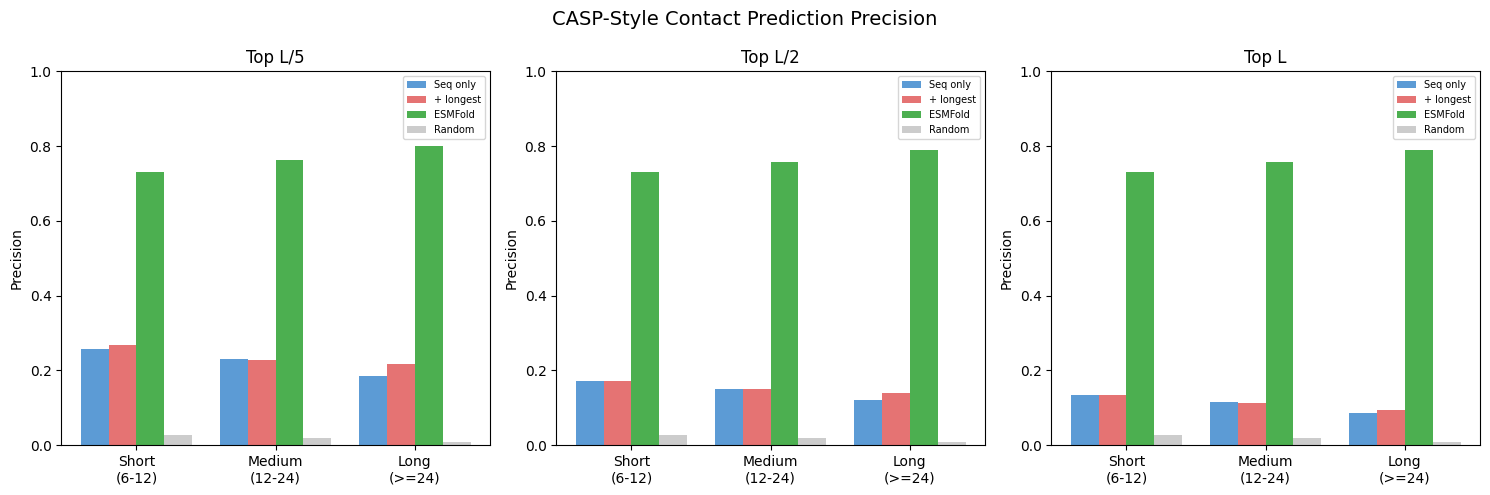

In [5]:
# Plot 1: CASP-style bar chart - all methods
CONDITION_STYLES = [
    ("seq_only", "#5C9BD5", "Seq only"),
    ("with_longest", "#E57373", "+ longest"),
    ("esmfold", "#4CAF50", "ESMFold"),
]
# Only include conditions present in data
cond_styles = [(c, col, lab) for c, col, lab in CONDITION_STYLES if c in df["condition"].values]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k_name in zip(axes, ["L/5", "L/2", "L"]):
    ranges = ["short", "medium", "long"]
    x = np.arange(len(ranges))
    n_bars = len(cond_styles) + 1  # +1 for random
    w = 0.8 / n_bars
    
    for ci, (condition, color, label) in enumerate(cond_styles):
        vals = [df[(df["condition"]==condition) & (df["range"]==r) & (df["k_name"]==k_name)]["precision"].mean()
                for r in ranges]
        ax.bar(x + ci * w - 0.4 + w/2, vals, w, label=label, color=color)
    
    # Random baseline
    rand_vals = [df[(df["condition"]==cond_styles[0][0]) & (df["range"]==r) & (df["k_name"]==k_name)]["random_precision"].mean()
                for r in ranges]
    ax.bar(x + len(cond_styles) * w - 0.4 + w/2, rand_vals, w, label="Random", color="#CCCCCC")
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Short\n(6-12)", "Medium\n(12-24)", "Long\n(>=24)"])
    ax.set_ylabel("Precision")
    ax.set_title(f"Top {k_name}")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

fig.suptitle("CASP-Style Contact Prediction Precision", fontsize=14)
plt.tight_layout()
plt.show()

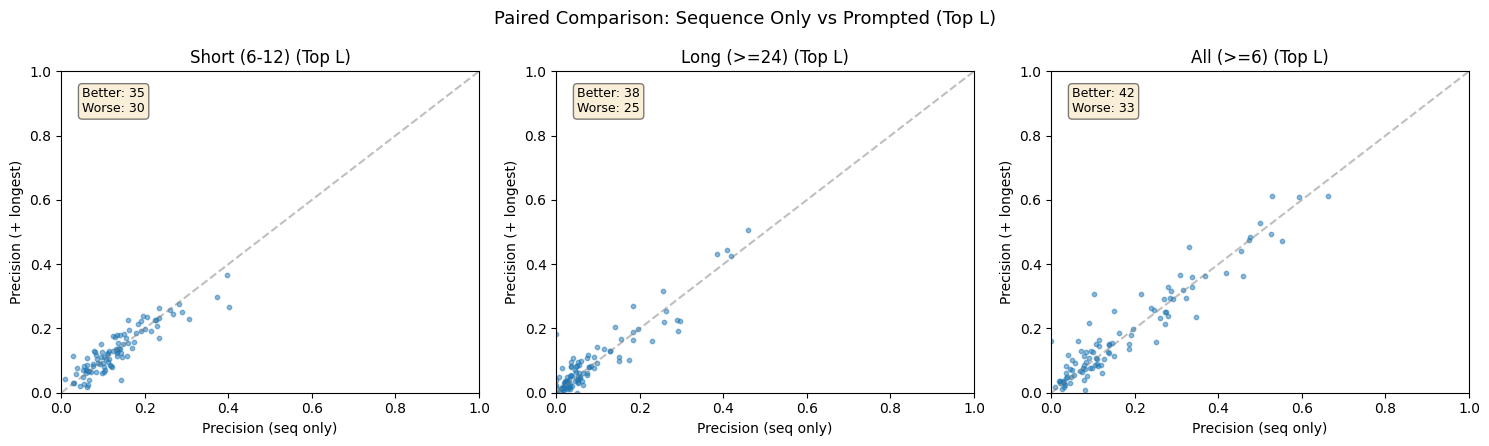

In [6]:
# Plot 2: Paired comparison scatter - does prompting help?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, range_name, title in zip(axes,
    ["short", "long", "all_6+"],
    ["Short (6-12)", "Long (>=24)", "All (>=6)"]):
    
    seq_prec = df[(df["condition"]=="seq_only") & (df["range"]==range_name) & (df["k_name"]=="L")]
    wl_prec = df[(df["condition"]=="with_longest") & (df["range"]==range_name) & (df["k_name"]=="L")]
    
    # Merge on entry_id
    merged = seq_prec[["entry_id", "precision"]].merge(
        wl_prec[["entry_id", "precision"]], on="entry_id", suffixes=("_seq", "_wl"))
    
    ax.scatter(merged["precision_seq"], merged["precision_wl"], s=10, alpha=0.5)
    ax.plot([0, 1], [0, 1], "--", color="grey", alpha=0.5)
    ax.set_xlabel("Precision (seq only)")
    ax.set_ylabel("Precision (+ longest)")
    ax.set_title(f"{title} (Top L)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    improved = (merged["precision_wl"] > merged["precision_seq"] + 0.01).sum()
    worsened = (merged["precision_seq"] > merged["precision_wl"] + 0.01).sum()
    ax.text(0.05, 0.95, f"Better: {improved}\nWorse: {worsened}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle("Paired Comparison: Sequence Only vs Prompted (Top L)", fontsize=13)
plt.tight_layout()
plt.show()

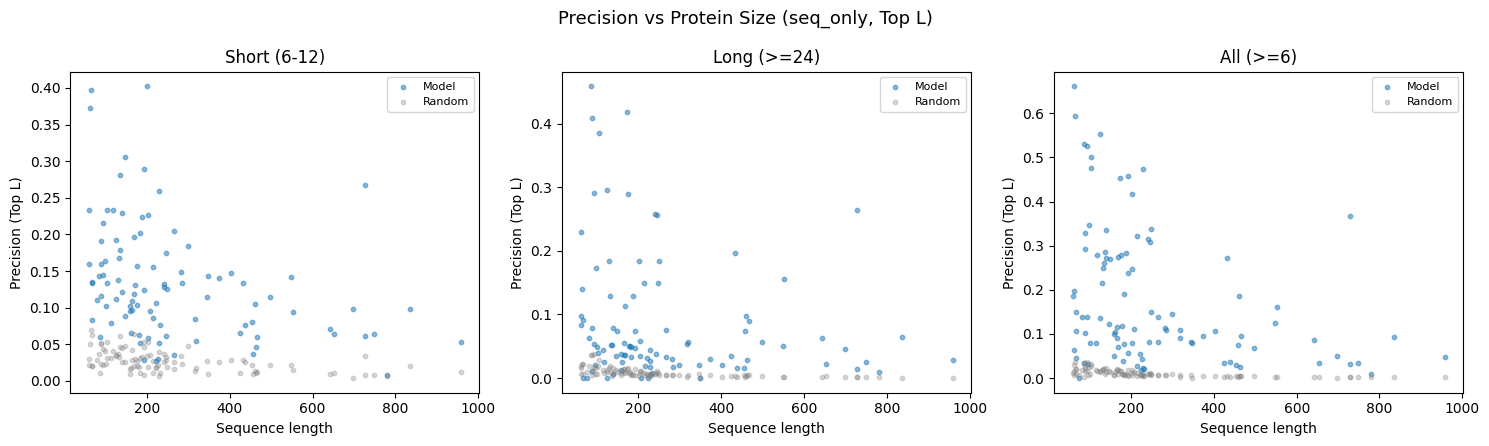

In [7]:
# Plot 3: Precision vs protein size
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, range_name, title in zip(axes,
    ["short", "long", "all_6+"],
    ["Short (6-12)", "Long (>=24)", "All (>=6)"]):
    
    sub = df[(df["condition"]=="seq_only") & (df["range"]==range_name) & (df["k_name"]=="L")]
    ax.scatter(sub["seq_len"], sub["precision"], s=10, alpha=0.5, label="Model")
    ax.scatter(sub["seq_len"], sub["random_precision"], s=10, alpha=0.3, color="grey", label="Random")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel(f"Precision (Top L)")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle("Precision vs Protein Size (seq_only, Top L)", fontsize=13)
plt.tight_layout()
plt.show()

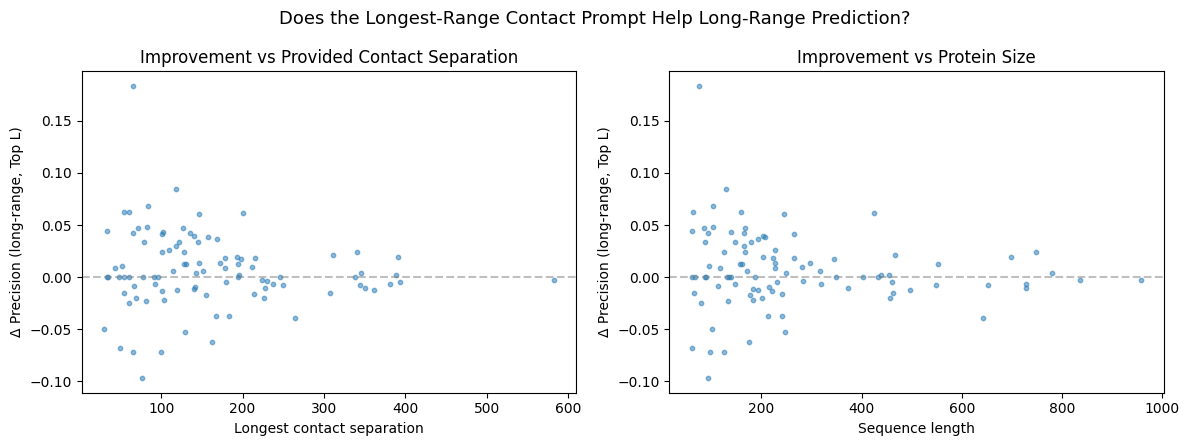

Long-range: mean Δprec=0.0066, improved=38/95, worsened=25/95


In [8]:
# Plot 4: Improvement from prompting vs properties
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# For long-range contacts specifically
seq_long = df[(df["condition"]=="seq_only") & (df["range"]=="long") & (df["k_name"]=="L")].set_index("entry_id")
wl_long = df[(df["condition"]=="with_longest") & (df["range"]=="long") & (df["k_name"]=="L")].set_index("entry_id")
common = seq_long.index.intersection(wl_long.index)
delta = wl_long.loc[common, "precision"].values - seq_long.loc[common, "precision"].values

ax = axes[0]
ax.scatter(seq_long.loc[common, "longest_sep"].values, delta, s=10, alpha=0.5)
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Longest contact separation")
ax.set_ylabel("\u0394 Precision (long-range, Top L)")
ax.set_title("Improvement vs Provided Contact Separation")

ax = axes[1]
ax.scatter(seq_long.loc[common, "seq_len"].values, delta, s=10, alpha=0.5)
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Sequence length")
ax.set_ylabel("\u0394 Precision (long-range, Top L)")
ax.set_title("Improvement vs Protein Size")

fig.suptitle("Does the Longest-Range Contact Prompt Help Long-Range Prediction?", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Long-range: mean \u0394prec={np.mean(delta):.4f}, "
      f"improved={np.sum(delta>0.01)}/{len(delta)}, "
      f"worsened={np.sum(delta<-0.01)}/{len(delta)}")

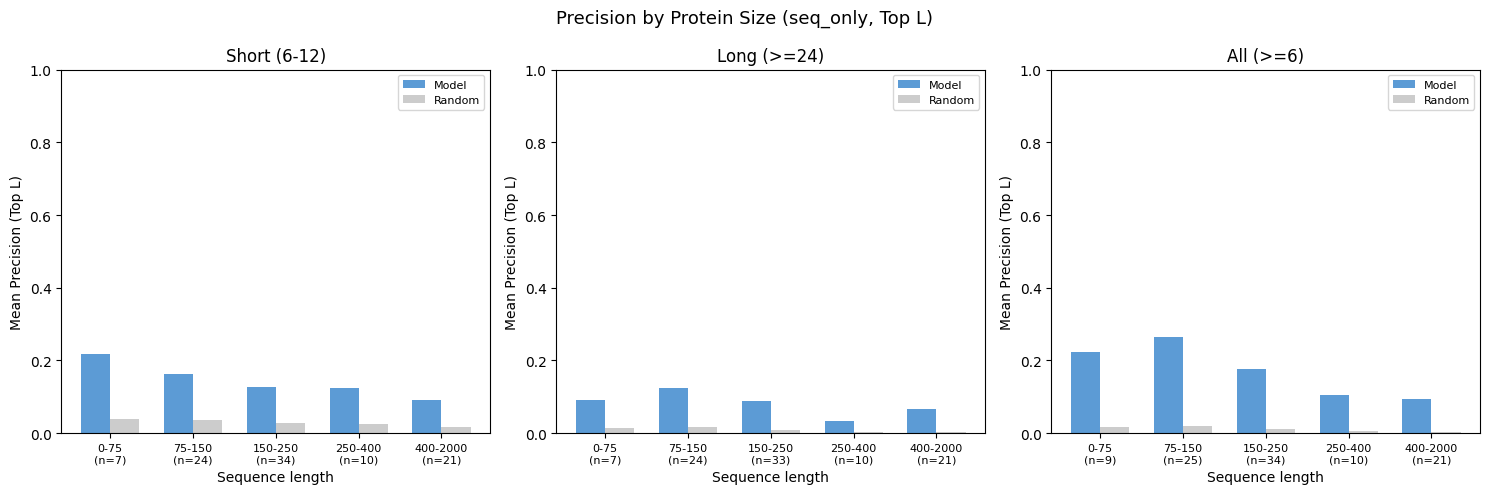

In [9]:
# Plot 5: Precision binned by sequence length
len_bins = [0, 75, 150, 250, 400, 2000]
bin_labels = [f"{len_bins[i]}-{len_bins[i+1]}" for i in range(len(len_bins)-1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, range_name, title in zip(axes,
    ["short", "long", "all_6+"],
    ["Short (6-12)", "Long (>=24)", "All (>=6)"]):
    
    sub = df[(df["condition"]=="seq_only") & (df["range"]==range_name) & (df["k_name"]=="L")].copy()
    sub["len_bin"] = pd.cut(sub["seq_len"], bins=len_bins, labels=bin_labels)
    
    model_means = sub.groupby("len_bin", observed=True)["precision"].mean()
    rand_means = sub.groupby("len_bin", observed=True)["random_precision"].mean()
    counts = sub.groupby("len_bin", observed=True)["precision"].count()
    
    x = np.arange(len(model_means))
    w = 0.35
    ax.bar(x - w/2, model_means, w, label="Model", color="#5C9BD5")
    ax.bar(x + w/2, rand_means, w, label="Random", color="#CCCCCC")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{l}\n(n={c})" for l, c in zip(model_means.index, counts)],
                       fontsize=8)
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Mean Precision (Top L)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

fig.suptitle("Precision by Protein Size (seq_only, Top L)", fontsize=13)
plt.tight_layout()
plt.show()

Consensus threshold analysis (seq_only)


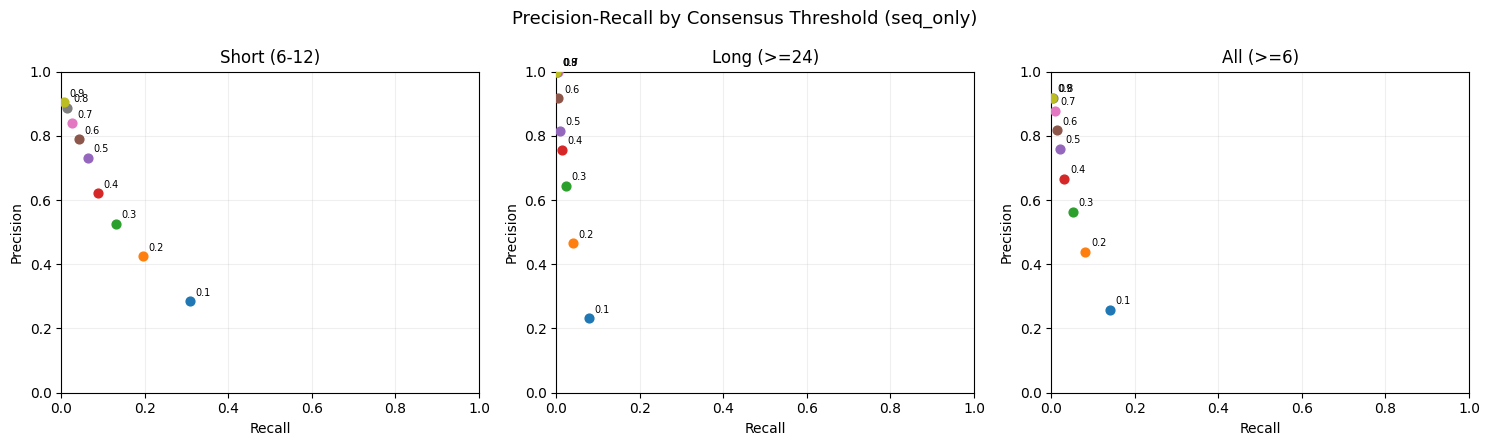

In [10]:
# Consensus threshold analysis (using seq_only condition)
# Instead of top-K, use consensus thresholds like in the visualization notebooks
print("Consensus threshold analysis (seq_only)")
print("=" * 70)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for rec in records:
    seq_len = rec["seq_len"]
    gt_contacts = parse_contacts(rec["gt_contacts"])
    gt_lt4 = contacts_to_lt4_pairs(gt_contacts)
    
    rollouts = rec["seq_only"]
    scored = rollouts_to_scored_pairs(rollouts, seq_len)
    
    for t in thresholds:
        pred = {p for p, s in scored if s > t}
        for range_name, (min_sep, max_sep) in CASP_RANGES.items():
            pred_r = {p for p in pred if abs(p[0]-p[1]) >= min_sep and (max_sep is None or abs(p[0]-p[1]) < max_sep)}
            gt_r = {p for p in gt_lt4 if abs(p[0]-p[1]) >= min_sep and (max_sep is None or abs(p[0]-p[1]) < max_sep)}
            n = len(pred_r)
            c = len(pred_r & gt_r)
            p = c / n if n else 0
            r = c / len(gt_r) if gt_r else 0
            f = 2*p*r/(p+r) if (p+r) else 0
            threshold_results.append({
                "entry_id": rec["entry_id"],
                "threshold": t,
                "range": range_name,
                "precision": p, "recall": r, "f1": f,
                "n_pred": n, "n_gt": len(gt_r),
            })

tdf = pd.DataFrame(threshold_results)

# Plot PR curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, range_name, title in zip(axes,
    ["short", "long", "all_6+"],
    ["Short (6-12)", "Long (>=24)", "All (>=6)"]):
    
    for t in thresholds:
        sub = tdf[(tdf["range"]==range_name) & (tdf["threshold"]==t)]
        # Aggregate: total correct / total pred
        total_correct = sub["n_pred"].values * sub["precision"].values
        total_pred = sub["n_pred"].sum()
        total_gt = sub["n_gt"].sum()
        p = total_correct.sum() / total_pred if total_pred else 0
        r = total_correct.sum() / total_gt if total_gt else 0
        ax.scatter(r, p, s=40, zorder=3)
        ax.annotate(f"{t}", (r, p), textcoords="offset points", xytext=(4, 4), fontsize=7)
    
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

fig.suptitle("Precision-Recall by Consensus Threshold (seq_only)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Final compact summary
print("\n" + "=" * 60)
print("COMPACT SUMMARY")
print("=" * 60)
print(f"Proteins: {len(records)}")
print(f"Rollouts per condition: {len(records[0]['seq_only'])}")
print(f"Seq len: {min(r['seq_len'] for r in records)}-{max(r['seq_len'] for r in records)} "
      f"(median {np.median([r['seq_len'] for r in records]):.0f})")
if esmfold_records:
    print(f"ESMFold results: {len(esmfold_records)} proteins")

all_conditions = [c for c in ["seq_only", "with_longest", "esmfold"] if c in df["condition"].values]
labels = {"seq_only": "Seq only", "with_longest": "+ longest", "esmfold": "ESMFold"}

for range_name, range_desc in [("long", "Long-range (|i-j|>=24)"), ("all_6+", "All (|i-j|>=6)")]:
    print(f"\nPrecision at Top L ({range_desc}):")
    for condition in all_conditions:
        sub = df[(df["condition"]==condition) & (df["range"]==range_name) & (df["k_name"]=="L")]
        rand = sub["random_precision"].mean()
        print(f"  {labels.get(condition, condition):>12s}: {sub['precision'].mean():.1%} (random: {rand:.1%})")


COMPACT SUMMARY
Proteins: 100
Rollouts per condition: 10
Seq len: 59-958 (median 193)
ESMFold results: 100 proteins

Precision at Top L (Long-range (|i-j|>=24)):
      Seq only: 8.7% (random: 0.9%)
     + longest: 9.4% (random: 0.9%)
       ESMFold: 79.0% (random: 0.9%)

Precision at Top L (All (|i-j|>=6)):
      Seq only: 17.8% (random: 1.1%)
     + longest: 18.6% (random: 1.1%)
       ESMFold: 77.3% (random: 1.1%)
